In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('social_media_addiction.csv')
df

,User_ID,Age,Gender,Platform,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Addiction_Level,Emotional_State_Post_Usage,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score
0,1001,23,Female,Instagram,145,3,120,25,45,40,High,Anxious,7,45,8
1,1002,19,Male,TikTok,210,1,45,5,10,85,Severe,Depressed,9,30,9
2,1003,28,Female,LinkedIn,45,0,5,2,15,10,Low,Motivated,2,80,3
3,1004,35,Male,Facebook,90,2,30,10,20,25,Moderate,Neutral,4,65,5
4,1005,21,Non-binary,Twitter,180,15,200,60,50,55,High,Stressed,8,40,7
5,1006,25,Male,YouTube,240,0,10,1,0,10,Severe,Bored,9,35,4
6,1007,31,Female,Instagram,60,1,50,8,30,20,Moderate,Happy,3,75,4
7,1008,22,Male,TikTok,165,5,90,12,35,70,High,Envious,6,50,8
8,1009,29,Female,Pinterest,30,0,2,0,5,15,Low,Inspired,1,85,2
9,1010,40,Male,Facebook,50,1,15,3,10,10,Low,Neutral,2,70,3


In [3]:
"""Quand nous regardons les premières analyses
nous pouvons croire que les plateforms les plus utilisés sons les suivantes:

>Facebook 3
>Instagram 3
>Tiktok 3
"""
"""Ce sont les resultats que nous obtenons quand nous analisons seulement une variable/colonne
pour l'application du paradox de Simpson, nous devons découvrir quelle variable 
apporte une information complementaire à notre variable principale, dans ce cas nous 
pouvons aussi utiliser la variable 'Daily_Usage_Time_min' qui est completement liée à 
l'utilisaiton de la platform, première variable analyse
"""

plt_ = (
    df
    .groupby('Platform')
    .size()
    .sort_values(ascending = False)
)
plt_

Platform
Facebook     3
Instagram    3
TikTok       3
Twitter      2
Snapchat     2
LinkedIn     2
YouTube      2
Discord      1
Reddit       1
Pinterest    1
dtype: int64

In [4]:
"""Donc si on veut appronfondir notre analyse, mettons 'Daily_Usage_Time_min', comme
variable complementaire du groupby principal"""

plt_c = (
     df
    .groupby('Platform')['Daily_Usage_Time_min']
    .sum()
    .sort_values(ascending = False)
)
plt_c

"""Voilà, on vient d'obtenir un autre resultat, la réalité des données change quand nous
analisons les plateformes plus accédées avec le temps d'utilisation"""
plt_c

Platform
TikTok       675
YouTube      370
Snapchat     365
Instagram    315
Twitter      300
Discord      200
Facebook     180
Reddit       150
LinkedIn      65
Pinterest     30
Name: Daily_Usage_Time_min, dtype: int64

In [8]:
smp = (
     df
    .groupby(['Gender','Platform'])['Daily_Usage_Time_min']
    .sum()
    .sort_values(ascending = False)
)
smp

Gender      Platform 
Male        TikTok       375
            YouTube      370
Female      Snapchat     365
            TikTok       300
            Instagram    205
Non-binary  Discord      200
            Twitter      180
Male        Reddit       150
            Facebook     140
            Twitter      120
            Instagram    110
Female      LinkedIn      65
            Facebook      40
            Pinterest     30
Name: Daily_Usage_Time_min, dtype: int64

In [11]:
pivot = df.pivot_table(
    values='Daily_Usage_Time_min',
    index='Platform',
    columns='Gender',
    aggfunc='mean'
)

pivot = pivot.T
pivot = pivot.fillna(0)
pivot

Platform,Discord,Facebook,Instagram,LinkedIn,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube
Gender,,,,,,,,,,
Female,0.0,40.0,102.5,32.5,30.0,0.0,182.5,300.0,0.0,0.0
Male,0.0,70.0,110.0,0.0,0.0,150.0,0.0,187.5,120.0,185.0
Non-binary,200.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,180.0,0.0


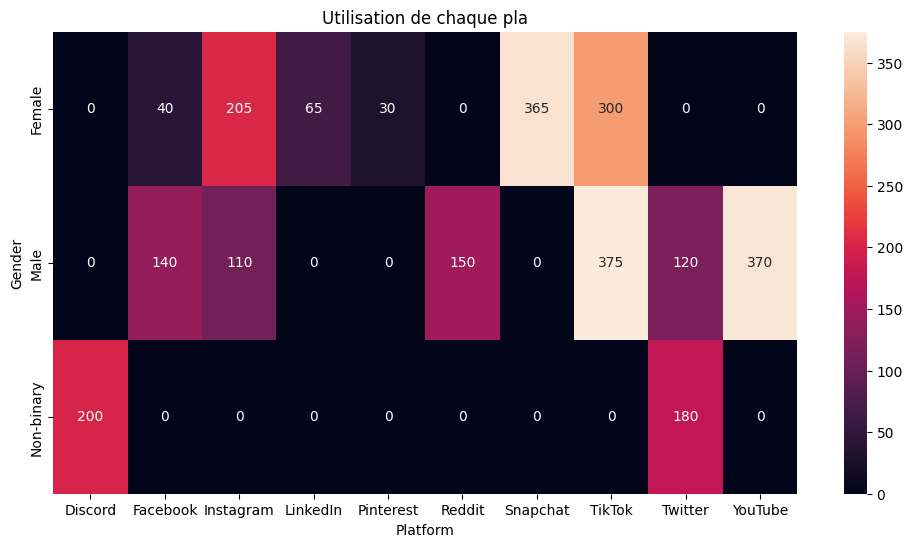

In [10]:
plt.figure(figsize=(12,6)) 
sns.heatmap(pivot, annot=True, fmt=".0f") 
plt.title("Utilisation de chaque pla")
plt.show() 